# Block delivery from relays - EDA

#### Maria Silva, July 2025


## 1. Imports

In [1]:
import os
import json
import pytz
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
from sqlalchemy import create_engine

In [2]:
# Main directories and files
current_path = os.getcwd()
repo_dir = os.path.abspath(os.path.join(current_path, ".."))

In [3]:
# plotting theme
sns.set_theme(
    style="whitegrid", palette="Set2", rc={"figure.dpi": 500, "axes.titlesize": 15}
)

In [4]:
def convert_slot_number_to_date_string(slot: int) -> str:
    slot_timestamp = slot * 12 + 1606824023
    slot_date = datetime.fromtimestamp(slot_timestamp, tz=pytz.timezone("UTC"))
    slot_date_str = slot_date.strftime("%Y-%m-%d %H:%M:%S")
    return slot_date_str

In [5]:
# Secrets for acessing xatu clickhouse and erigon
with open(os.path.join(repo_dir, "secrets.json"), "r") as file:
    secrets_dict = json.load(file)

# Credentials for xatu clickhouse
xatu_user = secrets_dict["xatu_username"]
xatu_pass = secrets_dict["xatu_password"]

db_url = db_url = (
        f"clickhouse+http://{xatu_user}:{xatu_pass}@"
        "clickhouse.xatu.ethpandaops.io:443/default?protocol=https"
    )

## 2. Data processing

### Ultrasound relay data

In [6]:
# Load raw data from ultrasound
ultra_file = os.path.join(
    repo_dir, "data", "relay", "ultrasoud_payload_publish_time_07_21_17_32.csv"
)
ultra_df = pd.read_csv(ultra_file)
ultra_df["request_datetime"] = pd.to_datetime(ultra_df["received_at"]).dt.tz_localize(
    None
)
ultra_df["publish_datetime"] = pd.to_datetime(
    ultra_df["time_before_publish"]
).dt.tz_localize(None)
ultra_df = ultra_df[ultra_df["is_ultra_sound_header"]]
ultra_df = ultra_df[["slot", "request_datetime", "publish_datetime"]]
ultra_df["source"] = "ultrasound"
ultra_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 91781 entries, 0 to 100257
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   slot              91781 non-null  int64         
 1   request_datetime  91781 non-null  datetime64[ns]
 2   publish_datetime  91781 non-null  datetime64[ns]
 3   source            91781 non-null  object        
dtypes: datetime64[ns](2), int64(1), object(1)
memory usage: 3.5+ MB


In [7]:
ultra_df["slot"].agg(["min", "max"])

min    11974663
max    12190656
Name: slot, dtype: int64

### Titan relay data

In [8]:
# Load raw data from titan
titan_file = os.path.join(repo_dir, "data", "relay", "block_times_since_12187616.csv")
titan_df = pd.read_csv(titan_file)
titan_df = titan_df.rename(columns={"slot_number": "slot"})
titan_df["request_datetime"] = pd.to_datetime(titan_df["signed_block_received"])
titan_df["publish_datetime"] = pd.to_datetime(titan_df["publishing_block"])
titan_df = titan_df[["slot", "request_datetime", "publish_datetime"]]
titan_df["source"] = "titan"
titan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3302 entries, 0 to 3301
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   slot              3302 non-null   int64         
 1   request_datetime  3302 non-null   datetime64[ns]
 2   publish_datetime  3302 non-null   datetime64[ns]
 3   source            3302 non-null   object        
dtypes: datetime64[ns](2), int64(1), object(1)
memory usage: 103.3+ KB


In [9]:
titan_df["slot"].agg(["min", "max"])

min    12187630
max    12262586
Name: slot, dtype: int64

### Slot times

In [10]:
# Define dates for queries
slot_start = 11974663
slot_end = 12262586
start_date_str = convert_slot_number_to_date_string(slot_start-2)
end_date_str = convert_slot_number_to_date_string(slot_end+2)
# Define and run query
query_str = f"""
    SELECT DISTINCT slot, slot_start_date_time AS slot_start_datetime
    FROM default.canonical_beacon_block FINAL
    WHERE slot_start_date_time BETWEEN toDateTime('{start_date_str}') AND toDateTime('{end_date_str}')
        AND meta_network_name = 'mainnet'
"""
engine = create_engine(db_url)
slot_start_df = pd.read_sql(query_str, con=engine)
slot_start_df["slot_start_datetime"] = pd.to_datetime(
    slot_start_df["slot_start_datetime"]
)
slot_start_df

,slot,slot_start_datetime
0,12041994,2025-06-30 23:59:11
1,12041995,2025-06-30 23:59:23
2,11992616,2025-06-24 03:23:35
3,11992628,2025-06-24 03:25:59
4,11992635,2025-06-24 03:27:23
...,...,...
286175,12231094,2025-07-27 06:19:11
286176,12231098,2025-07-27 06:19:59
286177,12231099,2025-07-27 06:20:11
286178,12231100,2025-07-27 06:20:23


### Join relay data

In [11]:
# Join data
relay_df = (
    pd.concat([ultra_df, titan_df], ignore_index=True)
    .merge(slot_start_df, on="slot", how="inner")
    .sort_values(by="request_datetime")
)
# Compute times
relay_df["request_to_publish"] = (
    relay_df["publish_datetime"] - relay_df["request_datetime"]
).dt.total_seconds()*1000
relay_df["slot_start_to_request"] = (
    relay_df["request_datetime"] - relay_df["slot_start_datetime"]
).dt.total_seconds()*1000
relay_df["slot_start_to_publish"] = (
    relay_df["publish_datetime"] - relay_df["slot_start_datetime"]
).dt.total_seconds()*1000
# Filter data bugs
# relay_df = relay_df[relay_df["slot_start_to_publish"].between(0,4000)]
# relay_df = relay_df[relay_df["slot_start_to_request"]>0]
# relay_df = relay_df[relay_df["request_to_publish"]>0]
# Get first request by slot
# relay_df = relay_df.groupby("slot").first().reset_index().sort_values(by="slot")
# relay_df = relay_df[relay_df["source"]=="titan"]
relay_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95043 entries, 91749 to 91750
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   slot                   95043 non-null  int64         
 1   request_datetime       95043 non-null  datetime64[ns]
 2   publish_datetime       95043 non-null  datetime64[ns]
 3   source                 95043 non-null  object        
 4   slot_start_datetime    95043 non-null  datetime64[ns]
 5   request_to_publish     95043 non-null  float64       
 6   slot_start_to_request  95043 non-null  float64       
 7   slot_start_to_publish  95043 non-null  float64       
dtypes: datetime64[ns](3), float64(3), int64(1), object(1)
memory usage: 6.5+ MB


In [12]:
relay_df["slot"].nunique()

95038

In [13]:
relay_df.groupby("source").size()

source
titan          3293
ultrasound    91750
dtype: int64

## 3. Time to request distribution

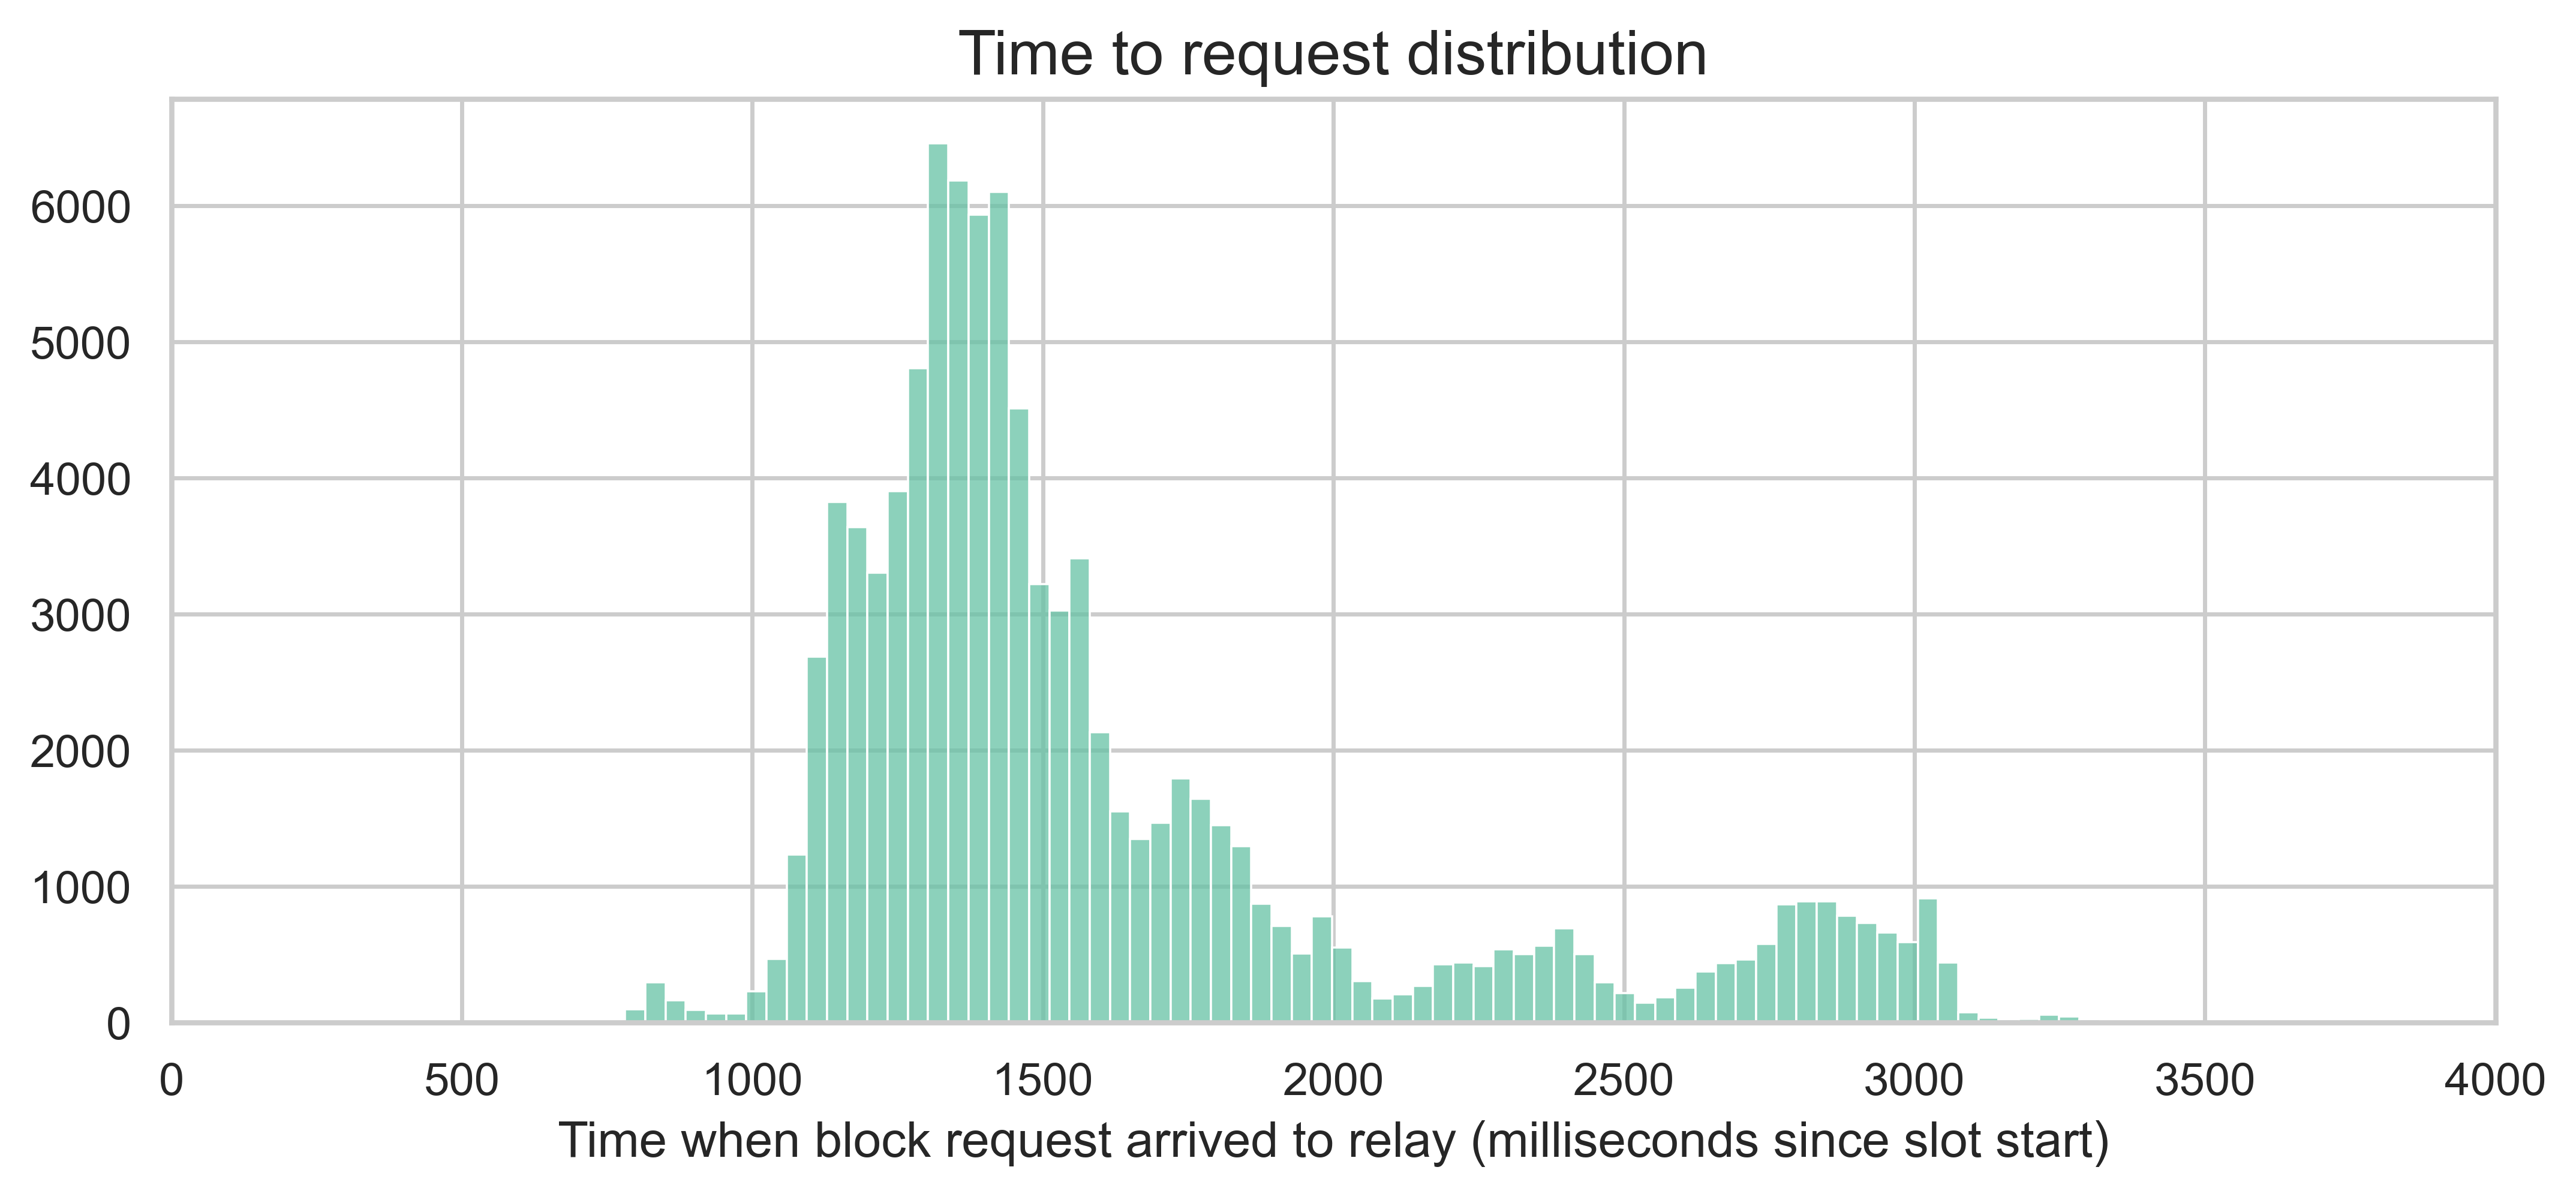

In [14]:
plt.figure(figsize=(10, 4))
sns.histplot(
    data=relay_df,
    x="slot_start_to_request",
    bins=100
)
plt.xlim(0,4000)
plt.title("Time to request distribution")
plt.ylabel("")
plt.xlabel("Time when block request arrived to relay (milliseconds since slot start)")
plt.show()

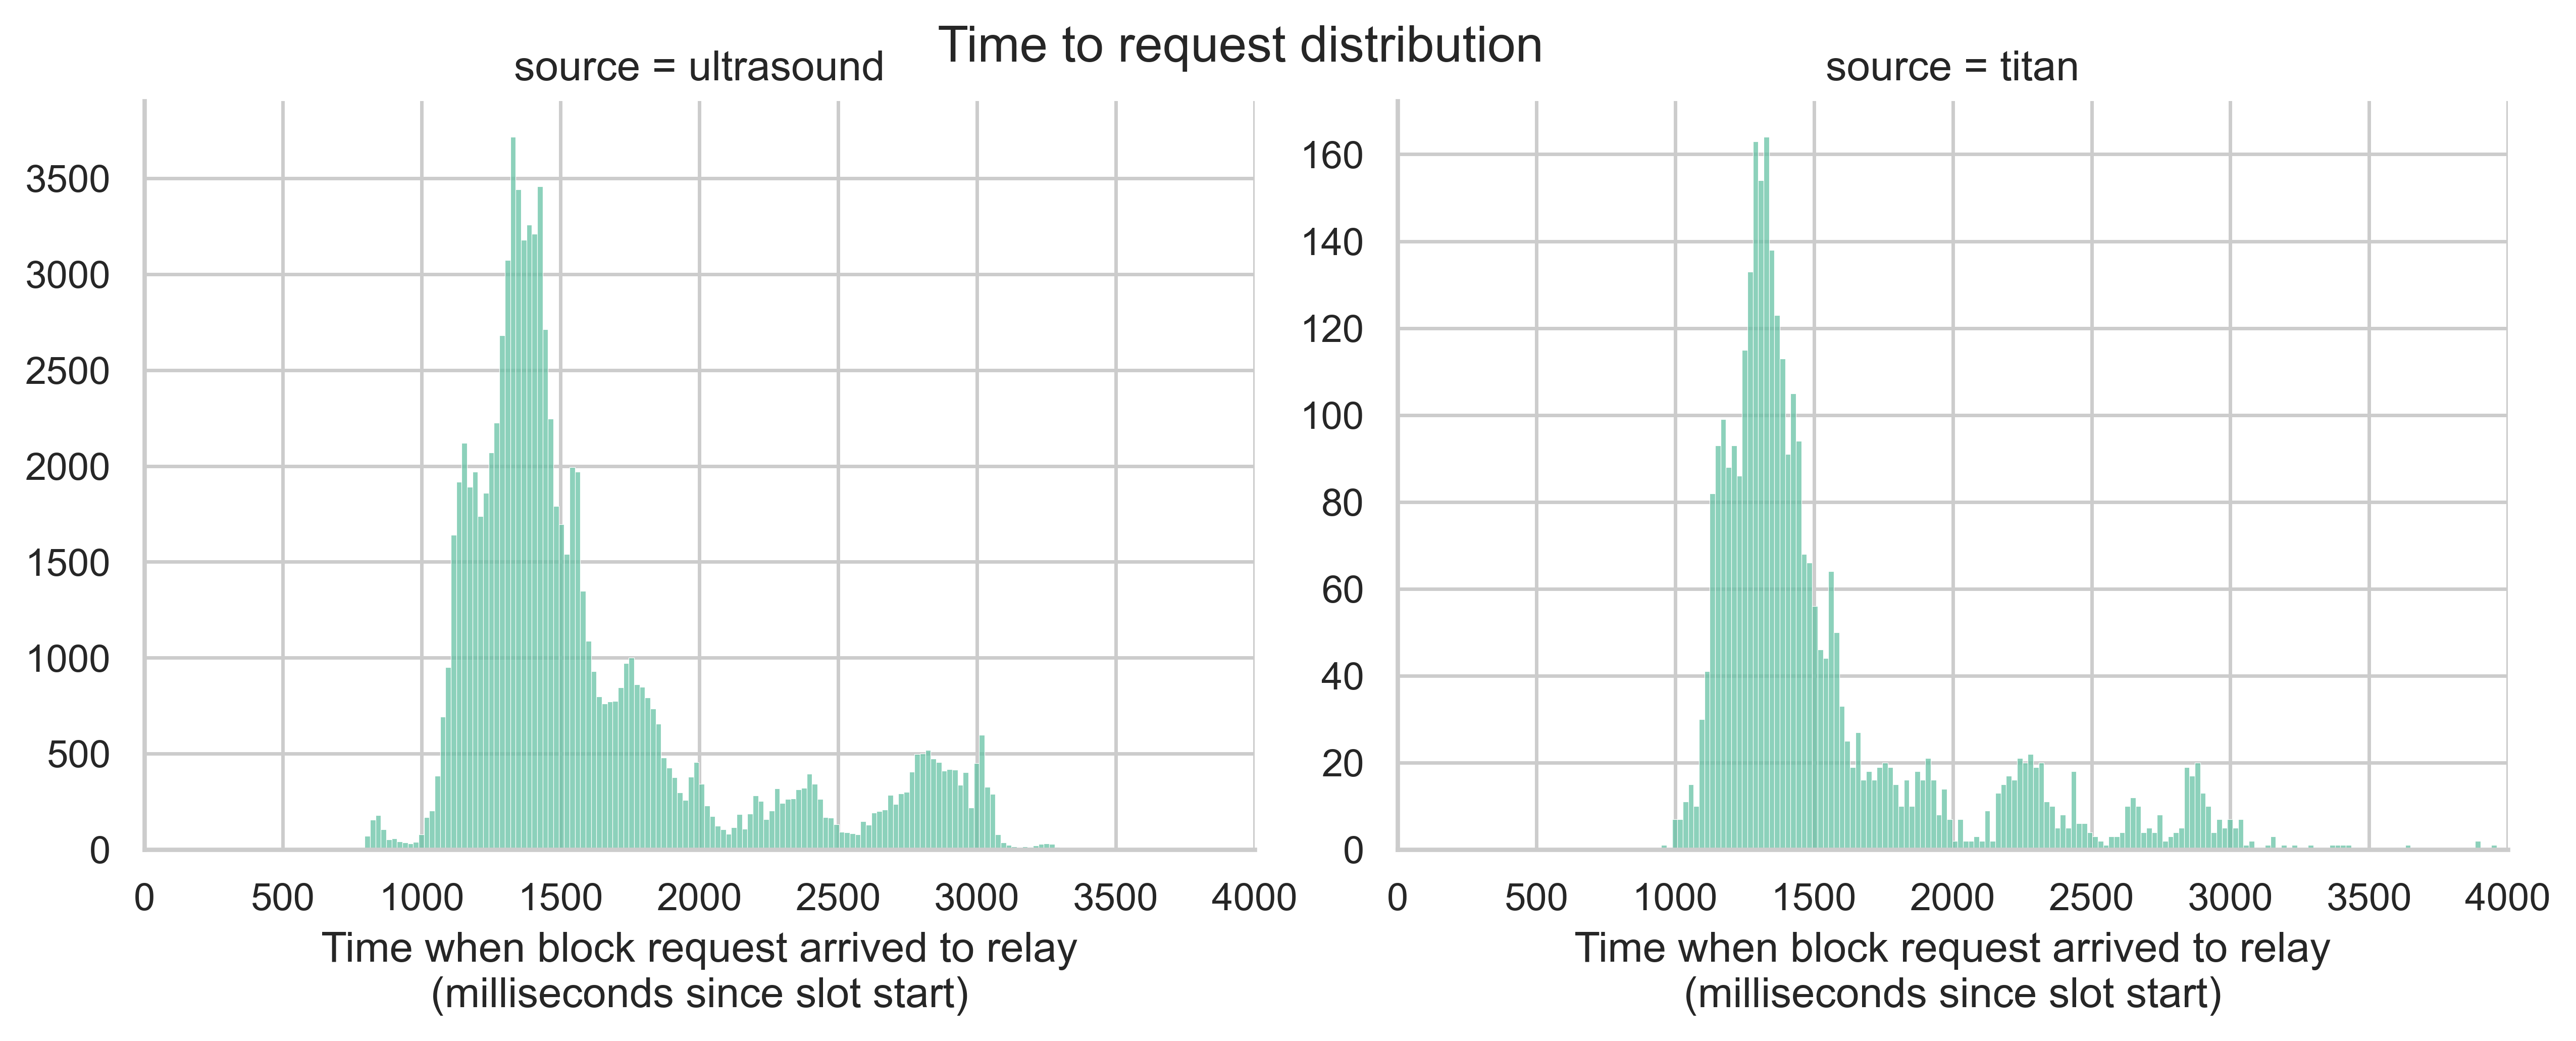

In [15]:

g = sns.displot(
    data=relay_df,
    x="slot_start_to_request",
    col="source",
    kind="hist",
    height=4, aspect=1.3,
    facet_kws={"sharey":False}
)
g.set(xlim=(0,4000))
g.set_xlabels("Time when block request arrived to relay\n(milliseconds since slot start)")
g.set_ylabels("")
plt.suptitle("Time to request distribution")
plt.show()

In [16]:
relay_df["slot_start_to_request"].agg(["min", "max", "mean", "std"])

min      503.000000
max     3979.000000
mean    1612.847548
std      511.679136
Name: slot_start_to_request, dtype: float64

In [17]:
relay_df["slot_start_to_request"].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

0.25    1295.000000
0.50    1428.000000
0.75    1740.000000
0.90    2539.814666
0.95    2856.489078
0.99    3033.000000
Name: slot_start_to_request, dtype: float64

## 4. Time to publish distribution

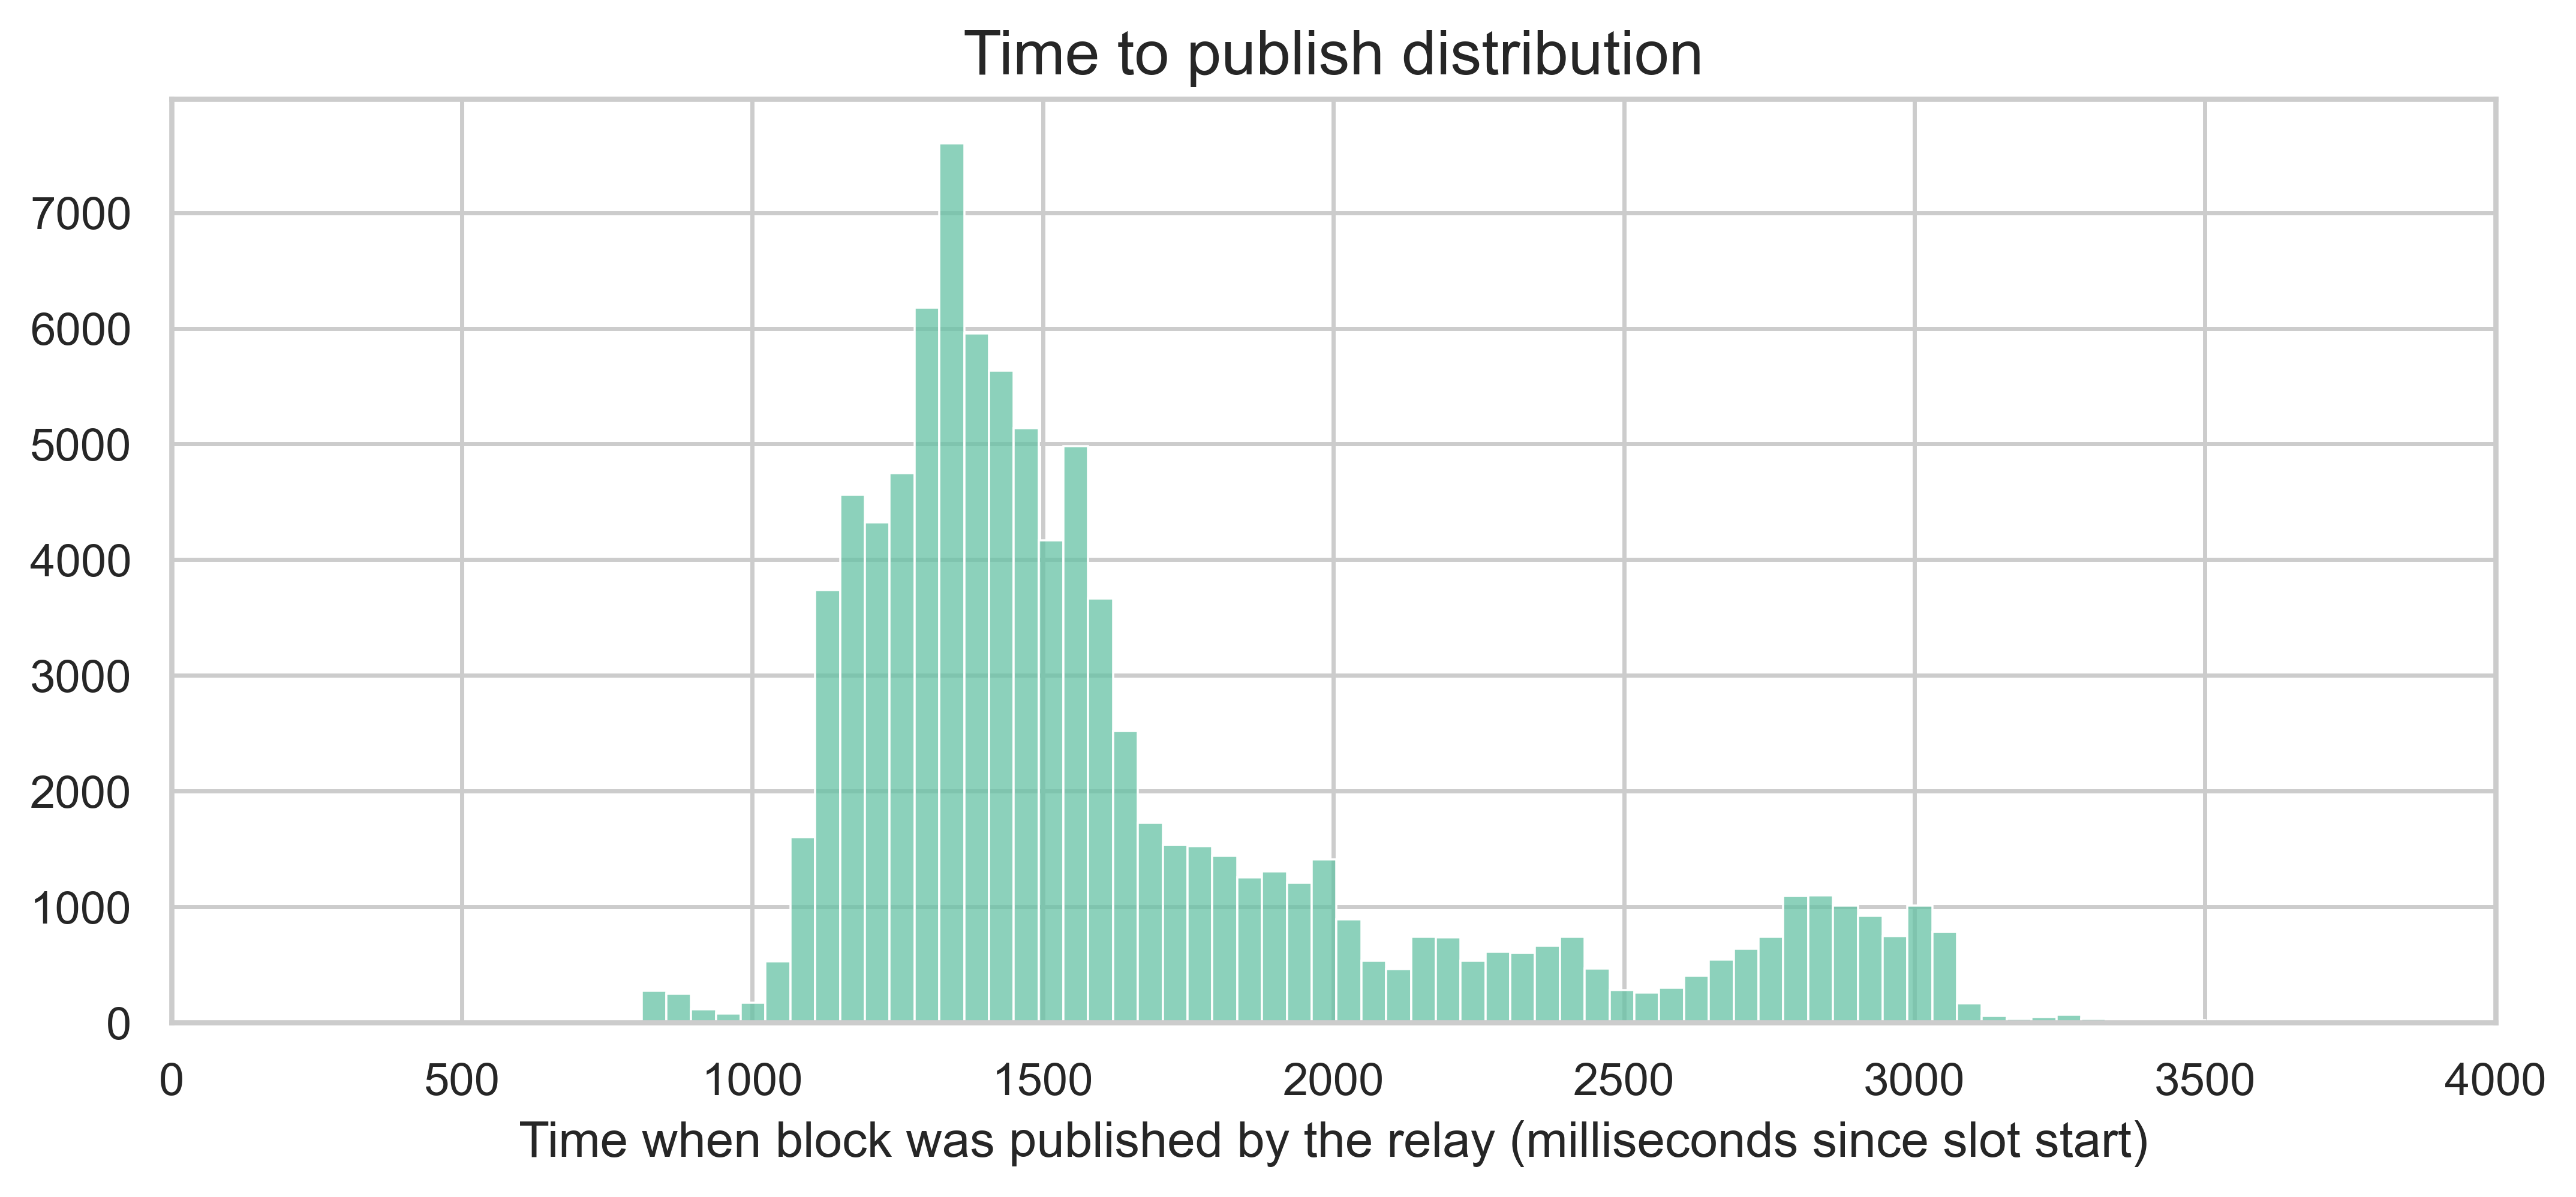

In [18]:
plt.figure(figsize=(10, 4))
sns.histplot(
    data=relay_df,
    x="slot_start_to_publish",
    bins=100
)
plt.xlim(0,4000)
plt.title("Time to publish distribution")
plt.ylabel("")
plt.xlabel("Time when block was published by the relay (milliseconds since slot start)")
plt.show()

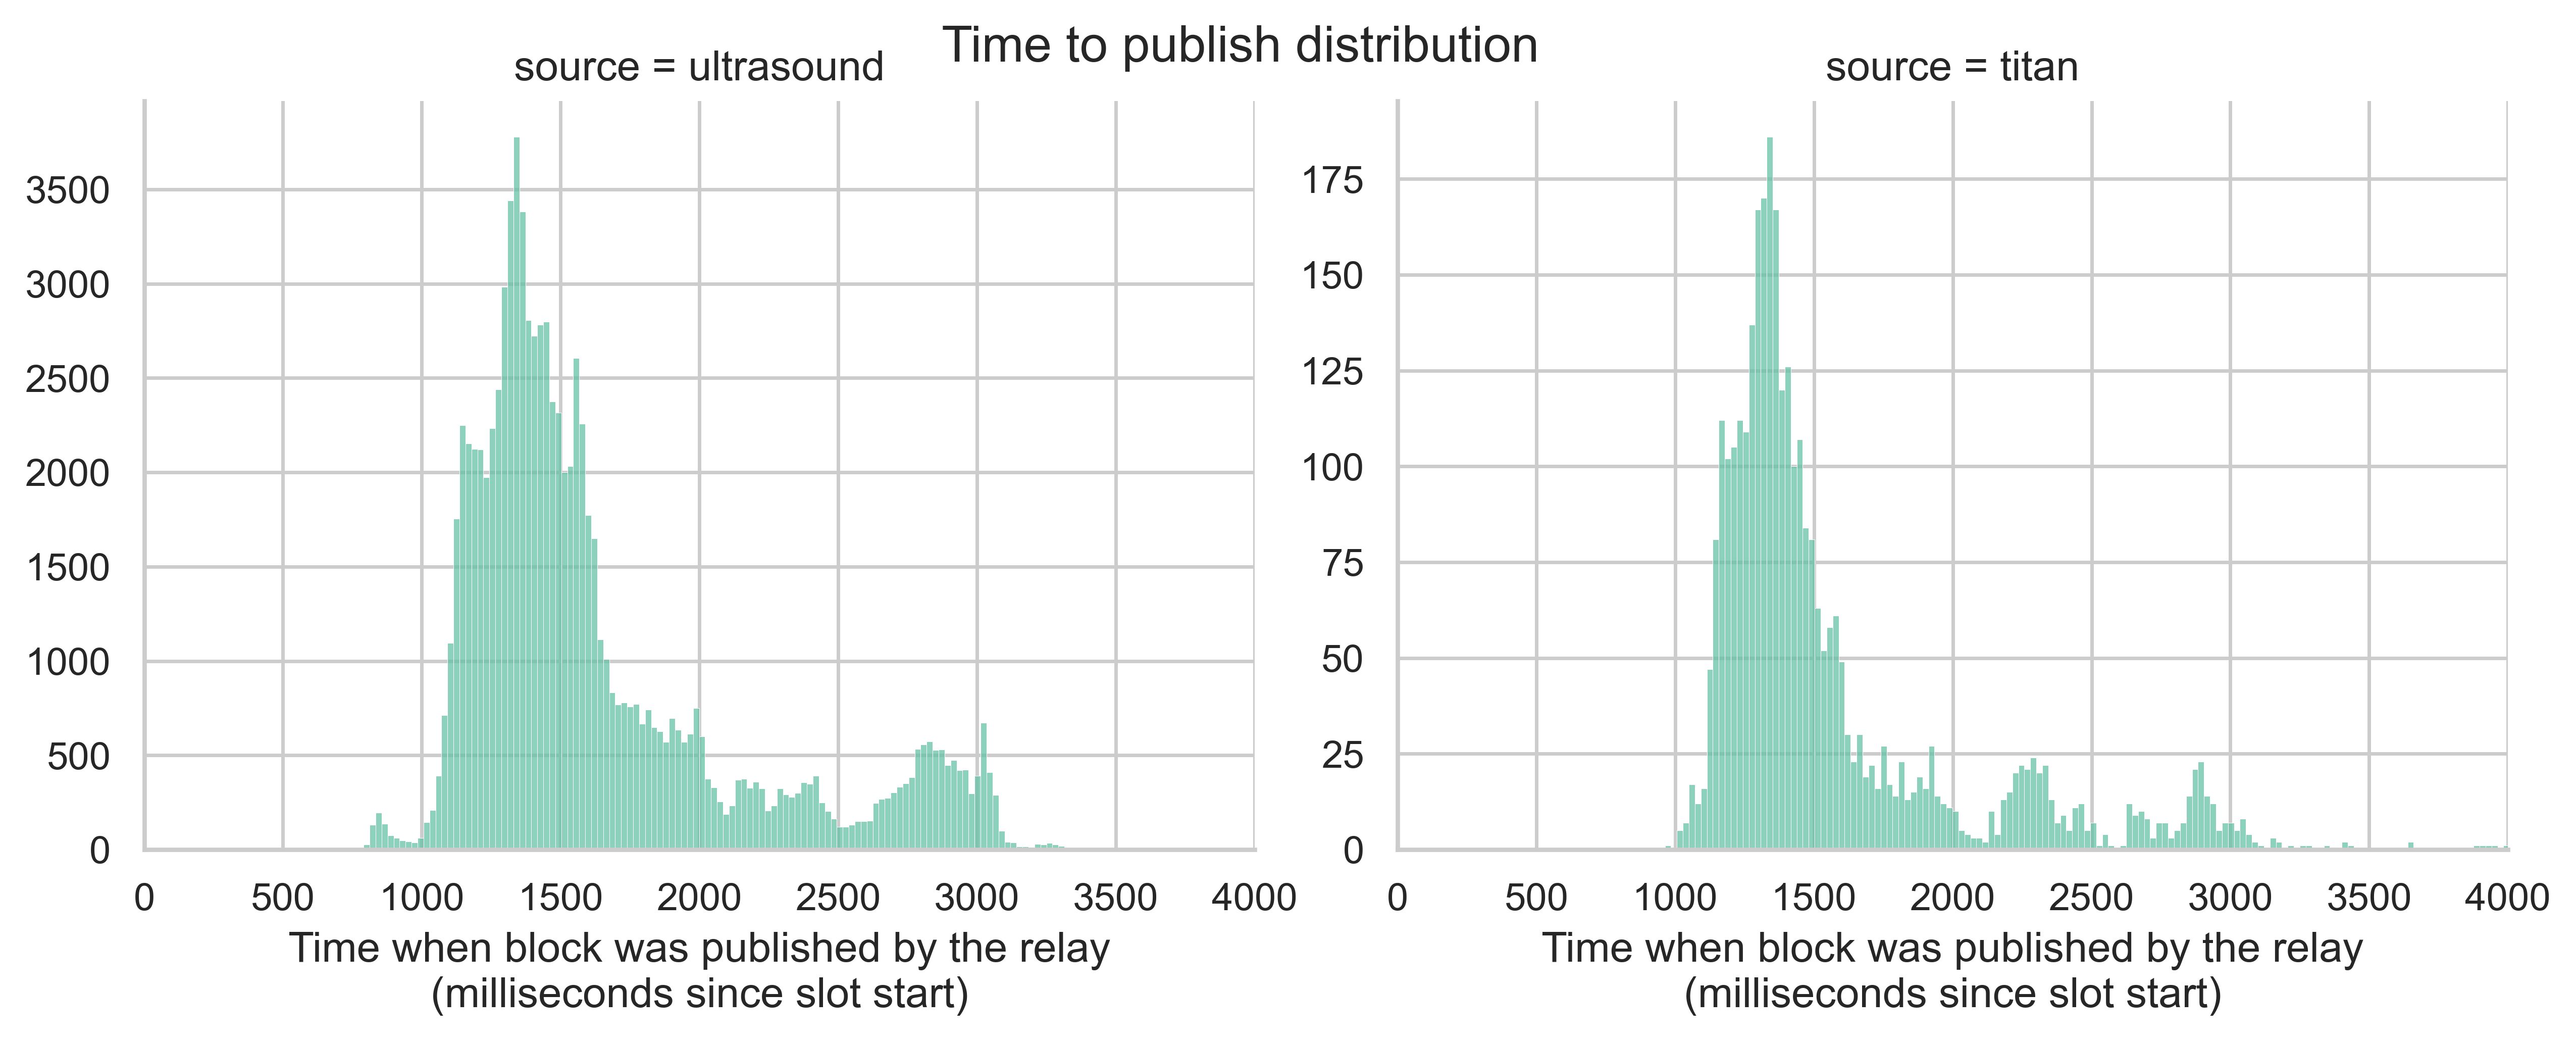

In [19]:

g = sns.displot(
    data=relay_df,
    x="slot_start_to_publish",
    col="source",
    kind="hist",
    height=4, aspect=1.3,
    facet_kws={"sharey":False}
)
g.set(xlim=(0,4000))
g.set_xlabels("Time when block was published by the relay\n(milliseconds since slot start)")
g.set_ylabels("")
plt.suptitle("Time to publish distribution")
plt.show()

In [20]:
relay_df["slot_start_to_publish"].agg(["min", "max", "mean", "std"])

min      510.000000
max     4782.308210
mean    1642.672047
std      519.073744
Name: slot_start_to_publish, dtype: float64

In [21]:
relay_df["slot_start_to_publish"].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

0.25    1304.0
0.50    1463.0
0.75    1798.0
0.90    2608.8
0.95    2869.0
0.99    3047.0
Name: slot_start_to_publish, dtype: float64